<a href="https://colab.research.google.com/github/naruto1265/CodSoft-Customer-Churn-Prediction/blob/main/SMS_SPAM_CLASSIFIER.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [5]:
# Download necessary NLTK data
nltk.download('stopwords')
ps = PorterStemmer()


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [6]:
# --- 1. DATA LOADING & CLEANING ---
# Using 'latin-1' because standard 'utf-8' often fails on this dataset
df = pd.read_csv('/content/spam.csv', encoding='latin-1')


In [7]:
# Drop unnecessary columns (usually v3, v4, v5 are empty)
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True, errors='ignore')


In [8]:
# Rename columns for clarity
df.rename(columns={'v1': 'target', 'v2': 'text'}, inplace=True)


In [9]:
# Encode target: ham -> 0, spam -> 1
df['target'] = df['target'].map({'ham': 0, 'spam': 1})


In [10]:
# --- 2. TEXT PREPROCESSING ---
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text) # Tokenization


In [11]:
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text) # Tokenization
    # Removing special characters, stopwords, and punctuation
    y = []
    for i in text:
        if i.isalnum() and i not in stopwords.words('english'):
            y.append(ps.stem(i)) # Stemming

    return " ".join(y)

In [12]:
# Example of preprocessing
nltk.download('punkt_tab') # Changed from 'punkt' to 'punkt_tab' as suggested by the error
df['transformed_text'] = df['text'].apply(transform_text)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [13]:
# --- 3. FEATURE EXTRACTION (TF-IDF) ---
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['transformed_text']).toarray()
y = df['target'].values


In [14]:
# --- 4. MODEL TRAINING ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [15]:
model = MultinomialNB()
model.fit(X_train, y_train)



MultinomialNB()

In [16]:
# --- 5. EVALUATION ---
y_pred = model.predict(X_test)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))




Accuracy Score: 0.9776

Confusion Matrix:
 [[965   0]
 [ 25 125]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99       965
           1       1.00      0.83      0.91       150

    accuracy                           0.98      1115
   macro avg       0.99      0.92      0.95      1115
weighted avg       0.98      0.98      0.98      1115



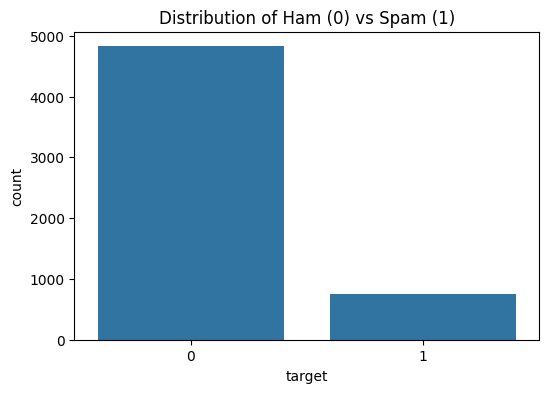

In [17]:
# --- 6. VISUALIZATION ---
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df)
plt.title('Distribution of Ham (0) vs Spam (1)')
plt.show()